# Velocity from gravity-free acceleration

This is the final goal of the pipeline. 

Velocity/speed satisfies the following equation:
$$
\frac{d\mathbf{v}}{dt} = \mathbf{a}(t)
$$
One could try to view this problem in two (related) ways: as ODE (ordinary differential equation) or as an integration problem. 

Viewing it as an ODE, there are some issues. Most (if not all) methods (Runge-Kutta, multistep) assume an available function of the independent and dependent variables that can be evaluated at different places. This isn't my case: I only have measurements, and I don't have a physical models of calisthenics exercises either. Trying to apply ODE methods anyway would necessarily need some form of curve fitting (e.g. regression, splines) prior to actually running the ODE method itself. This is obviously not viable for a device that has to run real-time on constrainted resources.   

Viewing it as an integration problem, applying the fundamental theorem of calculus, we have:

$$
\int_{t_i}^{t_i+1} d\mathbf{v} = \int_{t_i}^{t_i+1} \mathbf{a}(t) dt \newline
v_{x, t_i+1} = v_{x, t_i} + \int_{t_i}^{t_i+1} a_x(t) dt \newline
v_{y, t_i+1} = v_{y, t_i} + \int_{t_i}^{t_i+1} a_y(t) dt \newline
v_{z, t_i+1} = v_{z, t_i} + \int_{t_i}^{t_i+1} a_z(t) dt \newline
$$
This is a much simpler problem, since for $a(t)$ I can just apply well-known numerical integration formulas (Newton-Cotes, Adams-Moulton). To determine the best one, I'll run a series of tests: solving a simple ODE with known solution, solving the same ODE with an imperfect input, and finally solving the actual problem of velocity from acceleration. The best method is the one that gives the best results with least computational cost.

Sources:
* [Numerical methods for engineers](../../docs/misc/Numerical%20Methods%20for%20Engineers%20(7ed)%20-%20Chapra,%20Canale.pdf). Chapters 21, 25, 26.

## Setup

In [117]:
from scipy import integrate, stats
import numpy as np
import matplotlib.pyplot as plt


def cumulativeEuler(dy, x, dx):
    result = np.zeros_like(dy)
    for i in range(1, len(dy)):
        result[i] = result[i - 1] + dy[i - 1] * dx
    return result


def cumulativeClosedAdams3(dy, x, dx):
    result = np.zeros_like(dy)
    result[1] = (dy[0] + dy[1]) * dx / 2  # Trapezoid rule for the first step
    for i in range(2, len(dy)):
        result[i] = result[i - 1] + (dx / 12) * (5 * dy[i] + 8 * dy[i - 1] - dy[i - 2])
    return result


def computeErrors(trueValues, estimatedValues):
    errors = trueValues - estimatedValues
    rmse = np.sqrt(np.mean(errors**2))
    return (errors, rmse)


def plotODESolutions(axis, title, x, dx, x0, y, dy, y0):
    eulerSol = y0 + cumulativeEuler(dy, x=x, dx=dx)
    trapSol = y0 + integrate.cumulative_trapezoid(dy, x=x, dx=dx, initial=0)
    adams3Sol = y0 + cumulativeClosedAdams3(dy, x=x, dx=dx)
    simpsonSol = y0 + integrate.cumulative_simpson(dy, x=x, dx=dx, initial=0)

    errorsEuler, rmsEuler = computeErrors(y, eulerSol)
    errorsTrap, rmsTrap = computeErrors(y, trapSol)
    errorsAdams3, rmsAdams3 = computeErrors(y, adams3Sol)
    errorsSimpson, rmsSimpson = computeErrors(y, simpsonSol)

    axis.set_title(title)
    axis.plot(x, y, label="Analytical", color="red")
    axis.plot(
        x,
        eulerSol,
        label=f"Euler (RMSE={rmsEuler:.2e}, maxE={np.max(errorsEuler):.2e})",
        color="blue",
    )
    axis.plot(
        x,
        trapSol,
        label=f"Trapezoid (RMSE={rmsTrap:.2e}, maxE={np.max(errorsTrap):.2e})",
        color="green",
    )
    axis.plot(
        x,
        adams3Sol,
        label=f"Adams 3 (RMSE={rmsAdams3:.2e}, maxE={np.max(errorsAdams3):.2e})",
        color="purple",
    )
    axis.plot(
        x,
        simpsonSol,
        label=f"Simpson (RMSE={rmsSimpson:.2e}, maxE={np.max(errorsSimpson):.2e})",
        color="orange",
    )
    axis.legend(fontsize=8)
    axis.grid()

# Simple ODE with known solution
*Equation*: 
$\frac{dy}{dx} = -2x^3 + 12x^2 -20x+8.5, \text{ with } y(0) = 1$

*Conclusion*: 
* Euler is just bad ($O(h)$). It would only work well with very small step sizes and small integration windows. Don't use if possible.
* The other ones tend to be cluster together: Simpson ($O(h^4)$) is better than Adams3 ($O(h^3)$), which in turn is better than Trapezium ($O(h^2)$).
* On the device, Simpson would need a different implementation. Samples come as a stream, and only one is processed at a time. The solution would need to be provided every two samples, and I would need to be careful of not integrating the same sample twice. Adams-Moulton formulas are a better fit, since they use previous points to fit a polynomial but only integrate on the last interval.
* Higher order polynomials are probably not worth it.

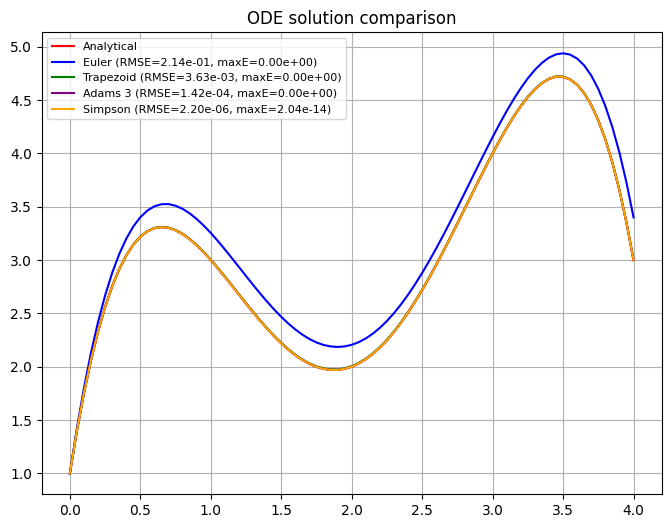

In [118]:
lowerBound = 0
upperBound = 4
dx = 0.05
x = np.arange(lowerBound, upperBound + dx, dx)
dy = -2 * x**3 + 12 * x**2 - 20 * x + 8.5
x0 = 0
y0 = 1
y = -0.5 * x**4 + 4 * x**3 - 10 * x**2 + 8.5 * x + 1

fig, axes = plt.subplots(figsize=(8, 6))
plotODESolutions(axes, "ODE solution comparison", x, dx, x0, y, dy, y0)
plt.show()

## ODE with various error sources

**General conclusion** (see below for details): 

The more imperfect the input is, the less the integration method or theoretical order matters. The only concession is not to choose Euler if possible, which is the only one that is consistently worse than the others. Focus more on mitigating noise, bias, drift and sampling jitter. 

**Choosen method**:

Trapezoid. The cheapest of the "good" ones, streaming-friendly.

### Noise

Normally distributed noise is chosen because it's the most common type. As a stress-test another, more pathological distribution (e.g. Cauchy) could be tried out later. 

*Conclusion*:

The more the signal is buried in noise, the less the integration method matters. However, Euler still performs worse than the others. Increasing the step size tends to help.

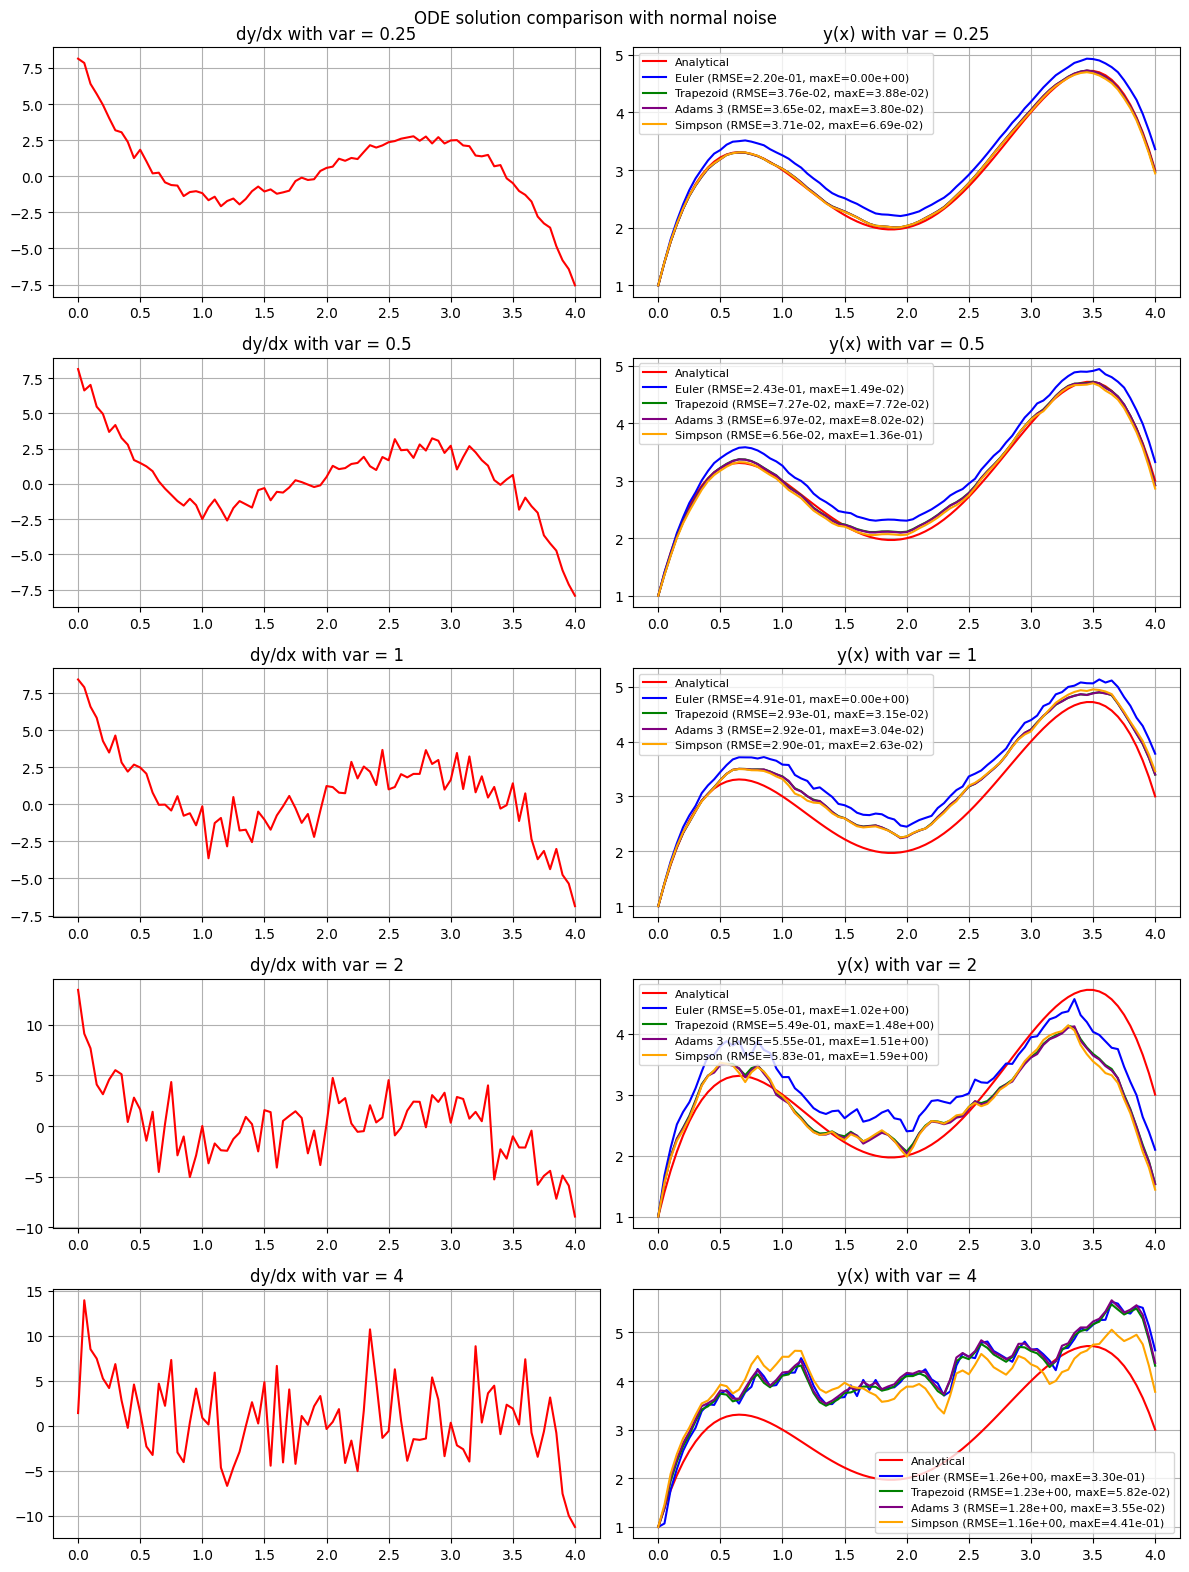

In [ ]:
seed = 12345  # Use always the same seed for reproducibility
rng = np.random.default_rng(seed)
vars = [0.25, 0.5, 1, 2, 4]
fig, axes = plt.subplots(len(vars), 2, figsize=(12, 16))
fig.suptitle("ODE solution comparison with normal noise")
for i, var in enumerate(vars):
    dyBiased = dy + stats.norm.rvs(loc=0, scale=var, size=len(dy), random_state=rng)
    axes[i, 0].plot(x, dyBiased, color="red")
    axes[i, 0].set_title(f"dy/dx with variance = {var}")
    axes[i, 0].grid()
    plotODESolutions(
        axes[i, 1], f"y(x) with variance = {var}", x, dx, x0, y, dyBiased, y0
    )
fig.tight_layout()
plt.show()

### Bias

Bias is modeled as a constant offset to the signal.

*Conclusion*:

Even small biases can make the integration diverge from the true solution.

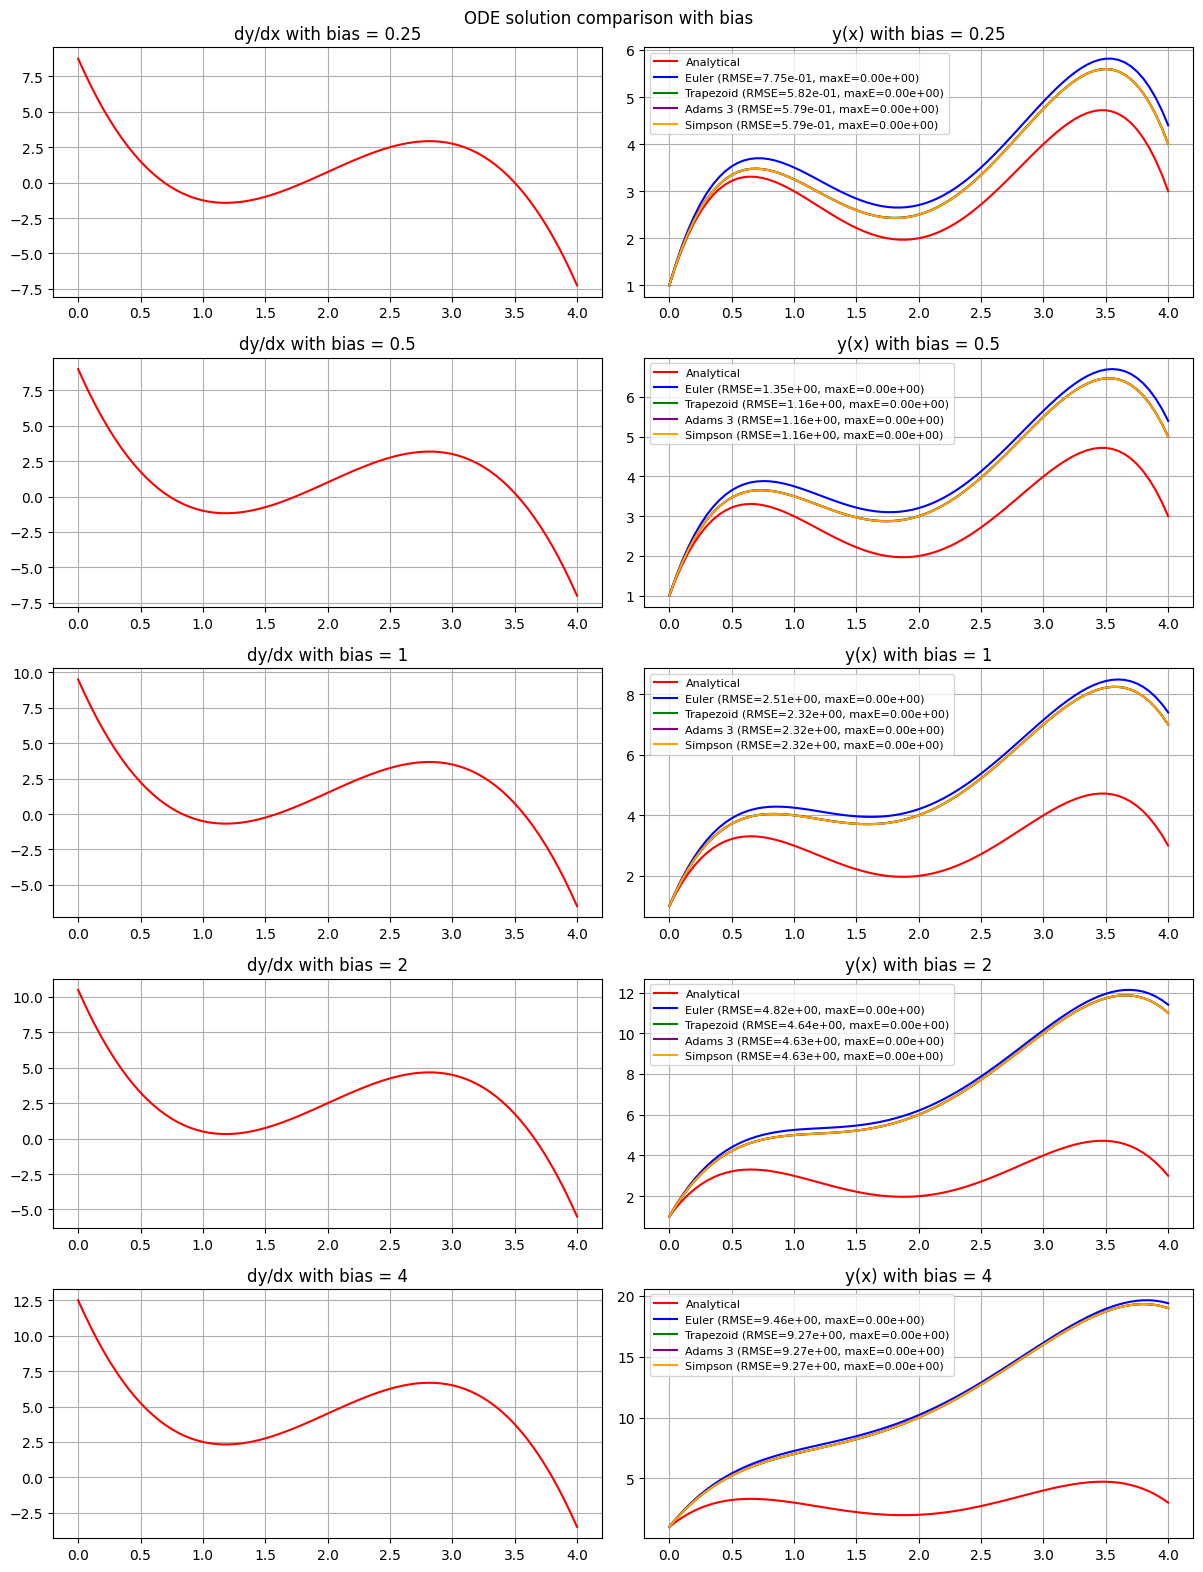

In [120]:
biases = [0.25, 0.5, 1, 2, 4]
fig, axes = plt.subplots(len(biases), 2, figsize=(12, 16))
fig.suptitle("ODE solution comparison with bias")
for i, bias in enumerate(biases):
    dyBiased = dy + bias
    axes[i, 0].plot(x, dyBiased, color="red")
    axes[i, 0].set_title(f"dy/dx with bias = {bias}")
    axes[i, 0].grid()
    plotODESolutions(axes[i, 1], f"y(x) with bias = {bias}", x, dx, x0, y, dyBiased, y0)
fig.tight_layout()
plt.show()

### Drift

Drift is modeled just as a linear function of time with a small slope and bias = 0.

*Conclusion*:

Unless the drift is very small, it will make the integration diverge from the true solution.

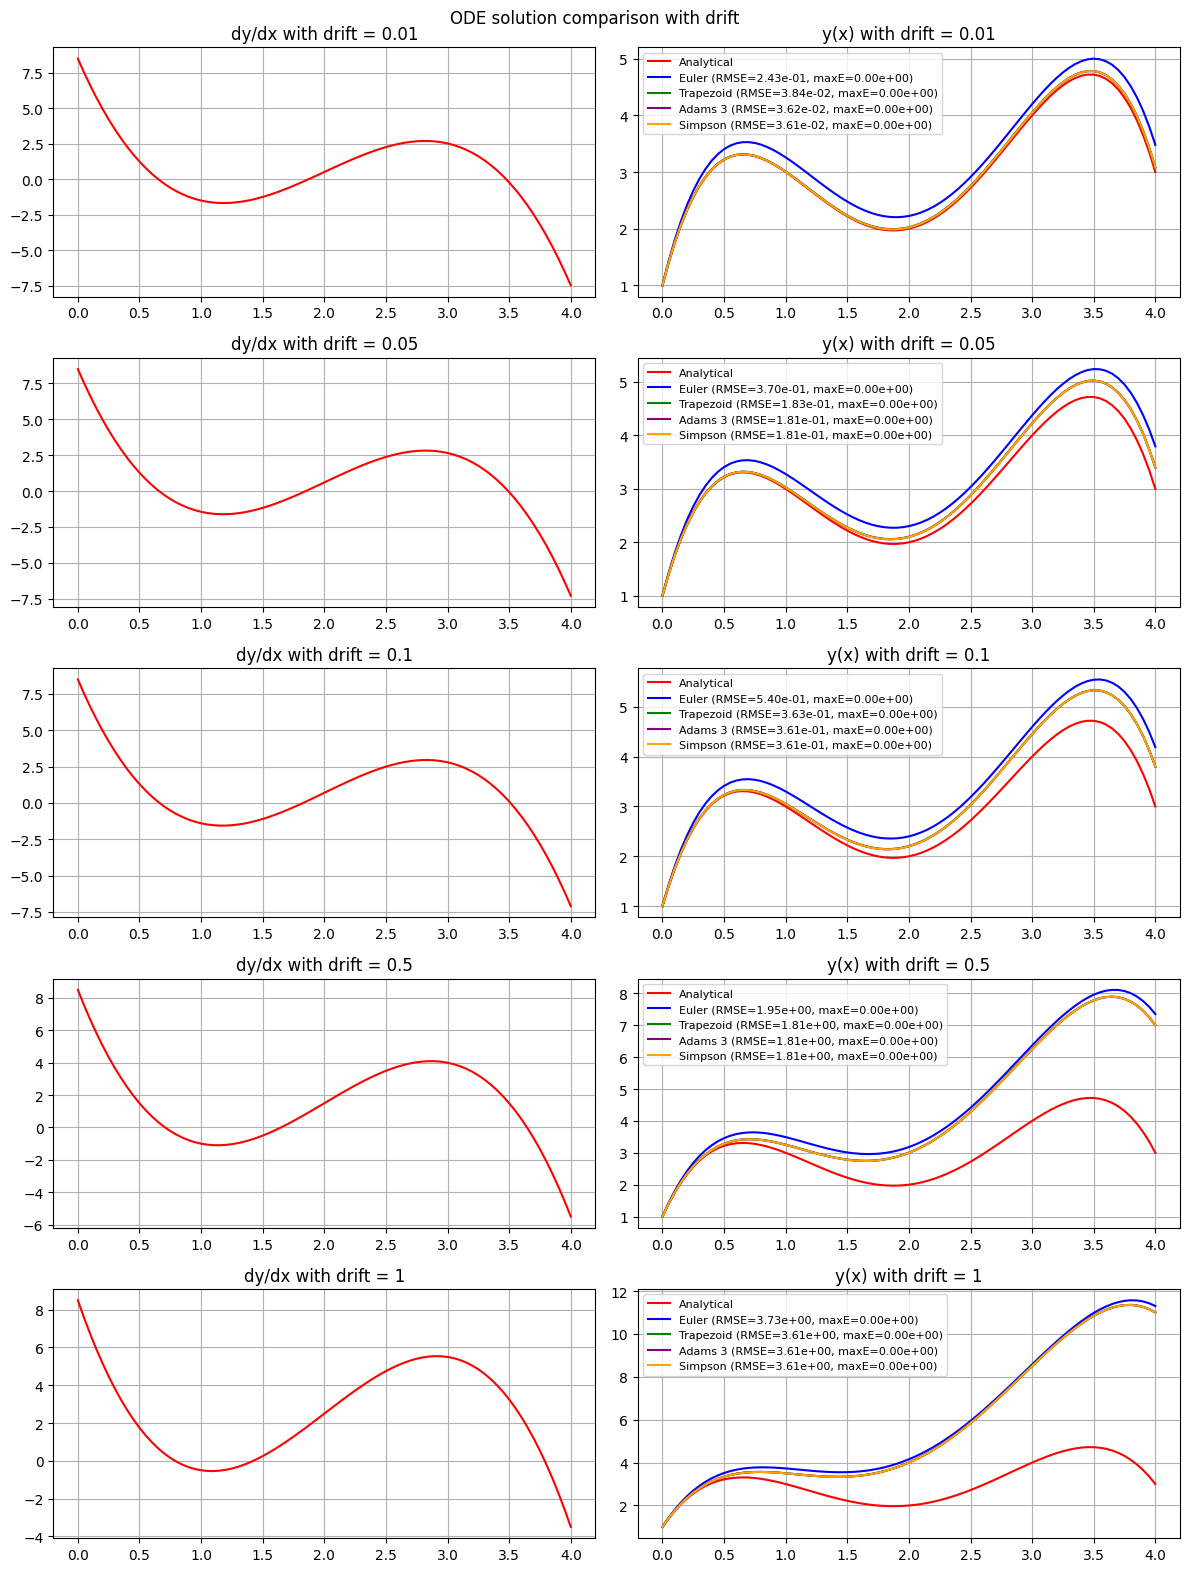

In [121]:
driftSlopes = [0.01, 0.05, 0.1, 0.5, 1]
fig, axes = plt.subplots(len(driftSlopes), 2, figsize=(12, 16))
fig.suptitle("ODE solution comparison with drift")
for i, slope in enumerate(driftSlopes):
    dyDrifted = dy + slope * x
    axes[i, 0].plot(x, dyDrifted, color="red")
    axes[i, 0].set_title(f"dy/dx with drift = {slope}")
    axes[i, 0].grid()
    plotODESolutions(
        axes[i, 1], f"y(x) with drift = {slope}", x, dx, x0, y, dyDrifted, y0
    )
fig.tight_layout()
plt.show()